# Reading data from files

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

In [2]:
spark=SparkSession.builder \
  .appName('myApp') \
  .getOrCreate()

**1) Create a DataFrame from CSV, JSON, and Parquet**

In [4]:
df_csv=spark.read \
            .format('csv') \
            .option('header', True) \
            .option('inferSchema', True) \
            .load('/content/files/employees.csv')
df_csv.show()

+---+------+---------+----------+------+------+
| id|  name|     city|department|salary|gender|
+---+------+---------+----------+------+------+
|  1|Subhag|     Pune|        IT| 50000|     M|
|  2|  Neha|    Delhi|        HR| 45000|     F|
|  3|  Amit|   Mumbai|        IT| 60000|     M|
|  4| Priya|Bangalore|   Finance| 55000|     F|
+---+------+---------+----------+------+------+



In [6]:
df_json=spark.read \
              .format('json') \
              .load('/content/files/employees1.json')

df_json.show()

+------+----------+---+------+------+
|  city|department| id|  name|salary|
+------+----------+---+------+------+
|  Pune|        IT|  1|Subhag| 50000|
| Delhi|        HR|  2|  Neha| 45000|
|Mumbai|        IT|  3|  Amit| 60000|
+------+----------+---+------+------+



In [9]:
df_json_multiline=spark.read \
                        .format('json') \
                        .option('multiline', True)\
                        .load('/content/files/employees_multiline.json')


df_json_multiline.show()


+-----+---+------+
| city| id|  name|
+-----+---+------+
| Pune|  1|Subhag|
|Delhi|  2|  Neha|
+-----+---+------+



In [11]:
df_parquet=spark.read \
                .format('parquet') \
                .option('inferSchema', True) \
                .load('/content/files/part-00000-tid-1964371512686279116-6925d4dc-2d10-4ed3-8617-31c4b75f9584-94-1.c000.snappy.parquet')

df_parquet.show()

+-----------+--------------+---------+---------+-------+-----------------+---------+-----------------+------------------+----+----------+----------+
|customer_id|          name|     city|    state|country|registration_date|is_active|registration_year|registration_month|rank|dense_rank|row_number|
+-----------+--------------+---------+---------+-------+-----------------+---------+-----------------+------------------+----+----------+----------+
|       6619| Customer_6619|Hyderabad|Karnataka|  India|       2023-12-31|     true|             2023|                12|   1|         1|         1|
|       7155| Customer_7155|  Chennai|Karnataka|  India|       2023-12-31|     true|             2023|                12|   1|         1|         2|
|      10153|Customer_10153|Bangalore|Karnataka|  India|       2023-12-31|     true|             2023|                12|   1|         1|         3|
|      12882|Customer_12882|  Chennai|Karnataka|  India|       2023-12-31|     true|             2023|    



---



**2) Read multiple CSV files**

You can pass a list of file paths to the CSV reader.

The CSV API explicitly supports a single string path or a list of paths.

In [15]:
df_multiple_csv=spark.read \
                      .format('csv') \
                      .option('inferSchema', True) \
                      .option('header', True) \
                      .load([
                          '/content/files/part2.csv' ,
                          '/content/files/part1.csv'
                      ])

df_multiple_csv.show()

+---+------+---------+
| id|  name|     city|
+---+------+---------+
|  3|  Amit|   Mumbai|
|  4| Priya|Bangalore|
|  1|Subhag|     Pune|
|  2|  Neha|    Delhi|
+---+------+---------+





---



**3) Read CSV file from directory**

If a directory contains multiple CSV files, point Spark to the directory.

In [20]:
dir_csv_df=spark.read \
                .format('csv') \
                .option('header', True) \
                .option('inferSchema', True) \
                .load('/content/files/csv')

dir_csv_df.show()

+---+------+---------+
| id|  name|     city|
+---+------+---------+
|  3|  Amit|   Mumbai|
|  4| Priya|Bangalore|
|  1|Subhag|     Pune|
|  2|  Neha|    Delhi|
+---+------+---------+





---



**4) Create custom schema while reading CSV without header**

In [21]:
schema=StructType([
    StructField('id', IntegerType(), True),
    StructField('name', StringType(), True),
    StructField('city', StringType(), True)
])

In [24]:
without_header_csv_df=spark.read \
  .format('csv') \
  .schema(schema) \
  .load('/content/files/employees_no_header.csv')

In [25]:

without_header_csv_df.show()

+---+------+------+
| id|  name|  city|
+---+------+------+
|  1|subhag|  pune|
|  2|  neha| delhi|
|  3|  amit|mumbai|
+---+------+------+



In [26]:
without_header_csv_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- city: string (nullable = true)





---



**5) Read CSV file when delimiter is |**

In [33]:
pipe_del_df=spark.read \
  .format('csv') \
  .schema(schema) \
  .option('inferSchema', True) \
  .option('sep', '|') \
  .load('/content/files/employees_pipe.csv')

In [34]:
pipe_del_df.show()

+---+------+------+
| id|  name|  city|
+---+------+------+
|  1|subhag|  pune|
|  2|  neha| delhi|
|  3|  amit|mumbai|
+---+------+------+



In [35]:

pipe_del_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- city: string (nullable = true)





---



**6) How to save a CSV file with mode**


Use df.write.mode(...).csv(...)

df.write.format("csv").mode(...).save(...)

In [36]:
pipe_del_df.write \
  .mode('overwrite') \
  .option('header', True) \
  .save('/content/files/csv')

In [38]:
pipe_del_df.write \
  .mode('append') \
  .option('header', True) \
  .save('/content/files/csv')

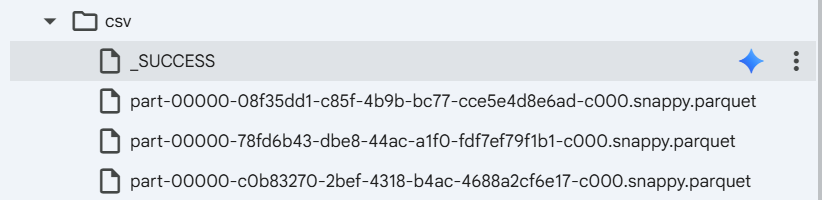



---



**7) Different modes while saving file**

Spark writer modes are:

1.   append
2.   overwrite
3.   error or errorifexists
4.   ignore

These control behavior when data already exists at the destination.

In [44]:
pipe_del_df.write.mode('append').save('/content/files/csv')

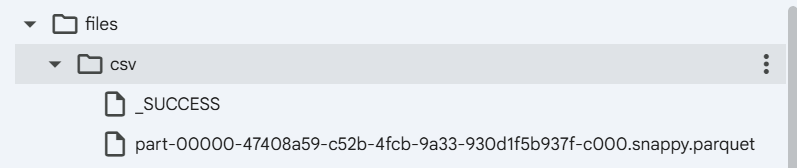

In [45]:
pipe_del_df.write.mode('overwrite').save('/content/files/csv')

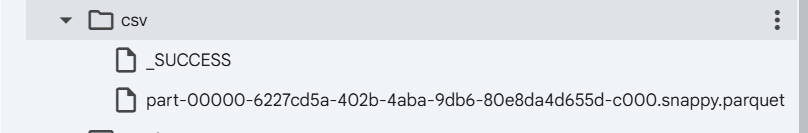

In [47]:
pipe_del_df.write.mode('ignore').save('/content/files/csv')

In [ ]:
pipe_del_df.write.mode('error').save('/content/files/csv')

## Meaning

**1.  append → add new data to existing data**

**2.  overwrite → replace existing data**

**3.  error / errorifexists → throw exception if path/table already exists**

**4.  ignore → do nothing if path/table already exists**



---



In [48]:
spark.stop()